In [89]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [90]:
# Extracting the close price data from yahoo finance
tickers = ['SPY']

df = yf.download(tickers, start="2010-01-01", auto_adjust=True)
df = df[['Close']].copy()
df.columns = df.columns.get_level_values(0)
df = df.dropna()
print(df)

[*********************100%***********************]  1 of 1 completed


Price            Close
Date                  
2010-01-04   84.368965
2010-01-05   84.592293
2010-01-06   84.651878
2010-01-07   85.009216
2010-01-08   85.292107
...                ...
2026-09-21  773.500000
2026-09-22  773.380005
2026-09-23  767.809998
2026-09-24  767.179993
2026-09-25  771.349976

[4208 rows x 1 columns]


Price            Close     ShortMA      LongMA  SMA_Signal
Date                                                      
2010-03-16   86.661903   83.948358   83.072731           1
2010-03-17   87.175560   84.202960   83.128863           1
2010-03-18   87.130890   84.431134   83.179635           1
2010-03-19   86.689865   84.628696   83.220395           1
2010-03-22   87.153320   84.848685   83.263277           1
...                ...         ...         ...         ...
2026-09-21  773.500000  762.988452  758.295245           1
2026-09-22  773.380005  763.578513  758.816560           1
2026-09-23  767.809998  763.768375  759.173406           1
2026-09-24  767.179993  763.918256  759.458199           1
2026-09-25  771.349976  764.026257  759.907991           1

[4159 rows x 4 columns]


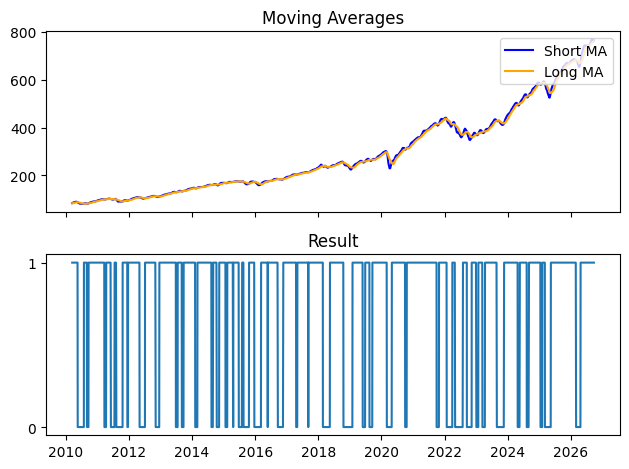

In [91]:
# Creating the short and long-term moving averages
short_window = 20
long_window = 50

def calculate_sma(close_prices, window):
  return close_prices.rolling(window = window).mean()

df['ShortMA'] = calculate_sma(df['Close'], short_window)
df['LongMA'] = calculate_sma(df['Close'], long_window)
df = df.dropna()

# When the short-term is above the long-term you buy
# When the long-term is above the short-term you sell
df['SMA_Signal'] = np.where(df['ShortMA'] > df['LongMA'], 1, 0)
print(df)

# Plotting the SMAs with the signal results
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig.subplots_adjust(hspace=0)

ax1.plot(df.index, df['ShortMA'], label = 'Short MA', color = 'blue')
ax1.plot(df.index, df['LongMA'], label = 'Long MA', color = 'orange')

ax1.set_title('Moving Averages')
ax1.legend(loc = 'upper right')


ax2.plot(df.index, df['SMA_Signal'])
ax2.set_yticks([0, 1])
ax2.set_title('Result')

plt.tight_layout()
plt.show()


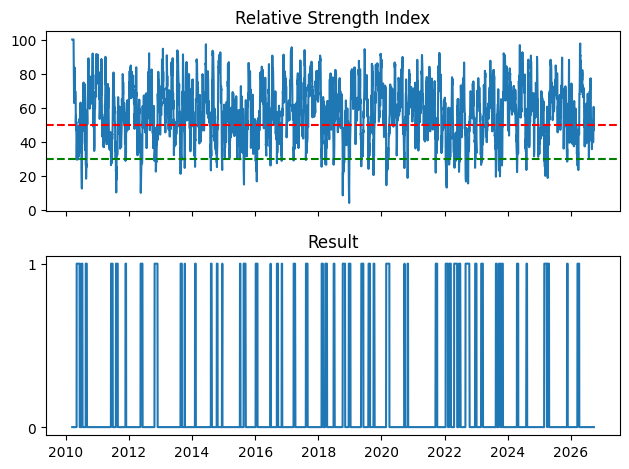

In [92]:
def compute_rsi(close_prices, rsi_window, entry_threshold, exit_threshold):
  # Generating the difference between close prices to find the gain and loss per day
  delta = close_prices.diff()

  # Determining the gain/loss per day
  gains = np.where(delta > 0, delta, 0)
  losses = np.where(delta < 0, -delta, 0)

  # Finding the average gain and the average loss
  RS_gain = pd.Series(gains, index = close_prices.index).rolling(window = rsi_window).mean()
  RS_loss = pd.Series(losses, index = close_prices.index).rolling(window = rsi_window).mean()

  # rs = (average gain over n days gain)/(average loss over n days loss)
  rs = np.where(RS_loss > 0, RS_gain / RS_loss, np.inf)
  rsi = 100 - (100 / (1 + rs)) # rsi formula

  return rsi, pd.Series(np.where(rsi < entry_threshold, 1, np.where(rsi > exit_threshold, 0, np.nan)), index = close_prices.index).ffill()

rsi_window = 14
# When the rsi < 30 and you sell only when rsi > 50
rsi_value, df['RSI_Signal'] = compute_rsi(df['Close'], rsi_window, 30, 50)

# Plotting the RSI with the signal results
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig.subplots_adjust(hspace=0)

ax1.plot(df.index, rsi_value)
ax1.axhline(y = 30, color='green', linestyle='--')
ax1.axhline(y = 50, color='red', linestyle='--')
ax1.set_title('Relative Strength Index')

ax2.plot(df.index, df['RSI_Signal'])
ax2.set_yticks([0, 1])
ax2.set_title('Result')

plt.tight_layout()
plt.show()


Date
2010-03-16         NaN
2010-03-17    0.005927
2010-03-18    0.005412
2010-03-19    0.000323
2010-03-22    0.005671
                ...   
2026-09-21    7.925491
2026-09-22    7.924106
2026-09-23    7.859833
2026-09-24    7.852563
2026-09-25    7.900681
Name: Daily_Returns, Length: 4159, dtype: float64
Date
2010-03-16         NaN
2010-03-17    0.005927
2010-03-18    0.005412
2010-03-19    0.000323
2010-03-22    0.005671
                ...   
2026-09-21    2.168451
2026-09-22    2.167959
2026-09-23    2.145143
2026-09-24    2.142562
2026-09-25    2.159644
Name: SMA_Returns, Length: 4159, dtype: float64
Date
2010-03-16         NaN
2010-03-17    0.000000
2010-03-18    0.000000
2010-03-19    0.000000
2010-03-22    0.000000
                ...   
2026-09-21    1.242681
2026-09-22    1.242681
2026-09-23    1.242681
2026-09-24    1.242681
2026-09-25    1.242681
Name: RSI_Returns, Length: 4159, dtype: float64


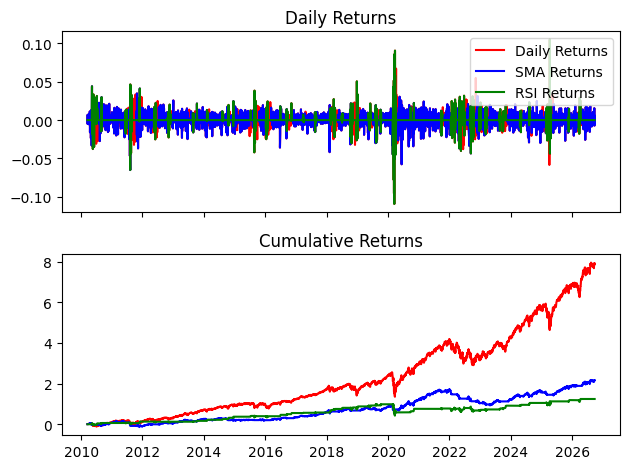

In [93]:
# Shifting both signals by a day since this is based on analysis of close prices
# We can only buy/sell during the next trading day
df['SMA_Position'] = df['SMA_Signal'].shift(1)
df['RSI_Position'] = df['RSI_Signal'].shift(1)

# Calculating the daily returns and multiplying with the signal columns to find out the returns on the day the signal suggested to have the stock
df['Daily_Returns'] = df['Close'].pct_change()
df['SMA_Returns'] = df['SMA_Position'] * df['Daily_Returns']
df['RSI_Returns'] = df['RSI_Position'] * df['Daily_Returns']

# Calculating the cumulative return
daily_return = (df['Daily_Returns'] + 1).cumprod() - 1
sma_return = (df['SMA_Returns'] + 1).cumprod() - 1
rsi_return = (df['RSI_Returns'] + 1).cumprod() - 1
print(daily_return)
print(sma_return)
print(rsi_return)

# Plotting the daily returns and cumulative returns of each strategy
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig.subplots_adjust(hspace=0)

ax1.plot(df.index, df['Daily_Returns'], label = 'Daily Returns', color = 'red')
ax1.plot(df.index, df['SMA_Returns'], label = 'SMA Returns', color = 'blue')
ax1.plot(df.index, df['RSI_Returns'], label = 'RSI Returns', color = 'green')

ax1.set_title('Daily Returns')
ax1.legend(loc = 'upper right')

ax2.plot(df.index, daily_return, label = 'Daily Returns', color = 'red')
ax2.plot(df.index, sma_return, label = 'SMA Returns', color = 'blue')
ax2.plot(df.index, rsi_return, label = 'RSI Returns', color = 'green')

ax2.set_title('Cumulative Returns')

plt.tight_layout()
plt.show()


In [94]:
# Creating the formulas for metrics to determine perfomance of each strategy
risk_free_rate = 0.0496
trading_days_per_year = 252
daily_rf = risk_free_rate / trading_days_per_year

# Measuring the risk-adjusted return
def sharpe_ratio(return_column):
  return (return_column.mean() - daily_rf)/return_column.std() * np.sqrt(trading_days_per_year)

# Calculating the Sharpe ratio of if you just held the stock, used sma strategy, or used rsi strategy
daily_sharpe = sharpe_ratio(df['Daily_Returns'])
sma_sharpe = sharpe_ratio(df['SMA_Returns'])
rsi_sharpe = sharpe_ratio(df['RSI_Returns'])

print("Daily Sharpe Ratio:", daily_sharpe)
print("SMA Sharpe Ratio:", sma_sharpe)
print("RSI Sharpe Ratio:", rsi_sharpe)
print()

# Finding the most the stock has dropped using the strategy
def max_drawdown(return_column):
  return ((return_column - return_column.cummax())/return_column.cummax()).min()

# Calculating the max drawdown of if you just held the stock, used sma strategy, or used rsi strategy
daily_drawdown = max_drawdown(daily_return + 1)
sma_drawdown = max_drawdown(sma_return + 1)
rsi_drawdown = max_drawdown(rsi_return + 1)

print("Daily Max Drawdown:", daily_drawdown)
print("SMA Max Drawdown:", sma_drawdown)
print("RSI Max Drawdown:", rsi_drawdown)

Daily Sharpe Ratio: 0.5712204896072752
SMA Sharpe Ratio: 0.23221547583819394
RSI Sharpe Ratio: 0.05033074086818289

Daily Max Drawdown: -0.33717288471525114
SMA Max Drawdown: -0.2888703225658571
RSI Max Drawdown: -0.28507330544075754


In [95]:
# Creating a train and test split
train = df.loc[:'2019-12-31']
test = df.loc['2020-01-01':]

close_train = train['Close'].squeeze()
close_test = test['Close'].squeeze()

# Testing different moving averages to find the most optimal one
sma_values = np.array([[5, 20], [10, 30], [20, 50], [50, 200]])

for i in sma_values:
  short_ma = calculate_sma(close_train, i[0])
  long_ma = calculate_sma(close_train, i[1])
  signal = pd.Series(np.where(short_ma > long_ma, 1, 0), index=train.index).shift(1)

  returns = signal * train['Daily_Returns'].squeeze()
  sharpe = sharpe_ratio(returns)

  cum_return = (returns + 1).cumprod()
  max_draw = max_drawdown(cum_return)
  print(i, "Sharpe Ratio: ", sharpe)
  print(i, "Max Drawdown: ", max_draw)
  print()

[ 5 20] Sharpe Ratio:  -0.0938626539513799
[ 5 20] Max Drawdown:  -0.22811945959619234

[10 30] Sharpe Ratio:  0.09748900773840721
[10 30] Max Drawdown:  -0.15026974328242887

[20 50] Sharpe Ratio:  0.21243918188937633
[20 50] Max Drawdown:  -0.24927230379352877

[ 50 200] Sharpe Ratio:  0.31256398751460573
[ 50 200] Max Drawdown:  -0.1917898694786977



In [96]:
# Testing different rsi windows, entry points, and exit points to find the most optimal one
rsi_values = np.array([[14, 30, 50], [14, 25, 60], [7, 30, 50], (21, 30, 70)])

for i in rsi_values:
  rsi, signal = compute_rsi(close_train, i[0], i[1], i[2])
  signal = signal.shift(1)

  returns = signal * train['Daily_Returns'].squeeze()
  sharpe = sharpe_ratio(returns)

  cum_return = (returns + 1).cumprod()
  max_draw = max_drawdown(cum_return)
  print(i, "Sharpe Ratio: ", sharpe)
  print(i, "Max Drawdown: ", max_draw)
  print()

[14 30 50] Sharpe Ratio:  0.2806945597333278
[14 30 50] Max Drawdown:  -0.1018306734588019

[14 25 60] Sharpe Ratio:  -0.06847144876150708
[14 25 60] Max Drawdown:  -0.08856738270659206

[ 7 30 50] Sharpe Ratio:  -0.01922191845113694
[ 7 30 50] Max Drawdown:  -0.16049430300831097

[21 30 70] Sharpe Ratio:  0.1980016509255733
[21 30 70] Max Drawdown:  -0.16120985611745056



Daily Sharpe Ratio: 0.5664452266177645
Daily Max Drawdown: -0.33717288471525125

SMA Sharpe Ratio: 0.36192459897732
SMA Max Drawdown: -0.33717288471525125

RSI Sharpe Ratio: -0.14794962366088676
RSI Max Drawdown: -0.2831903905365206



/tmp/ipykernel_935/1436175002.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Daily_Returns'] = test['Close'].squeeze().pct_change()


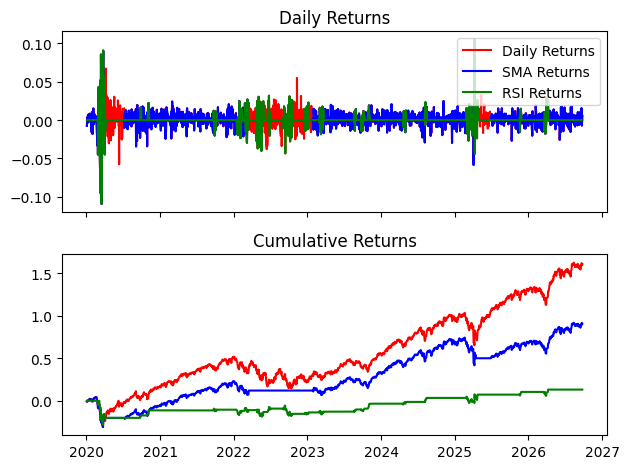

In [97]:
# Comparing the optimal sma values and rsi values with a strategy of holding the stock the whole time period
test['Daily_Returns'] = test['Close'].squeeze().pct_change()
daily_return = (test['Daily_Returns'] + 1).cumprod()
sharpe_daily = sharpe_ratio(test['Daily_Returns'])
max_draw_daily = max_drawdown(daily_return)
print("Daily Sharpe Ratio:", sharpe_daily)
print("Daily Max Drawdown:", max_draw_daily)
print()

# Used the full dataset instead of test for this since the first 200 days will have an NaN value
short_ma = calculate_sma(df['Close'].squeeze(), 50)
long_ma = calculate_sma(df['Close'].squeeze(), 200)
signal_sma = pd.Series(np.where(short_ma > long_ma, 1, 0), index=df.index).shift(1)
signal_sma = signal_sma.loc['2020-01-01':]

returns_sma = signal_sma * test['Daily_Returns'].squeeze()
sharpe_sma = sharpe_ratio(returns_sma)

cum_return_sma = (returns_sma + 1).cumprod()
max_draw_sma = max_drawdown(cum_return_sma)
print("SMA Sharpe Ratio:", sharpe_sma)
print("SMA Max Drawdown:", max_draw_sma)
print()

rsi_num, signal_rsi = compute_rsi(close_test, 14, 30, 50)
signal_rsi = signal_rsi.shift(1)
returns_rsi = signal_rsi * test['Daily_Returns'].squeeze()
sharpe_rsi = sharpe_ratio(returns_rsi)

cum_return_rsi = (returns_rsi + 1).cumprod()
max_draw_rsi = max_drawdown(cum_return_rsi)
print("RSI Sharpe Ratio:", sharpe_rsi)
print("RSI Max Drawdown:", max_draw_rsi)
print()

# Plotting the 3 strategies on the test dataset
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig.subplots_adjust(hspace=0)

ax1.plot(test.index, test['Daily_Returns'], label = 'Daily Returns', color = 'red')
ax1.plot(test.index, returns_sma, label = 'SMA Returns', color = 'blue')
ax1.plot(test.index, returns_rsi, label = 'RSI Returns', color = 'green')

ax1.set_title('Daily Returns')
ax1.legend(loc = 'upper right')

ax2.plot(test.index, daily_return - 1, label = 'Daily Returns', color = 'red')
ax2.plot(test.index, cum_return_sma - 1, label = 'SMA Returns', color = 'blue')
ax2.plot(test.index, cum_return_rsi - 1, label = 'RSI Returns', color = 'green')

ax2.set_title('Cumulative Returns')

plt.tight_layout()
plt.show()

ML Sharpe Ratio: 0.39294224408065664
ML Max Drawdown: -0.3051864394015242
ML Accuracy: 0.5035460992907801


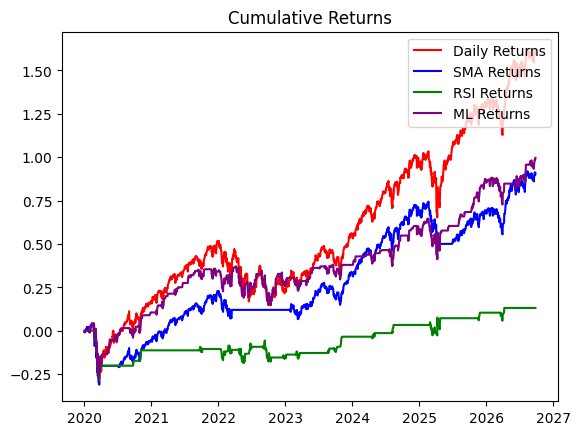

In [99]:
# Calculating metrics for the ML model to use to try and create a strategy
df['MA_spread'] = (df['ShortMA'] - df['LongMA']) / df['LongMA']
df['RSI_value'] = rsi_value
df['Volatility_10'] = df['Daily_Returns'].rolling(10).std()

# Determines if there was a gain or a loss every day
df['Label'] = np.where(df['Daily_Returns'].shift(-1) > 0, 1, 0)

features = ['MA_spread', 'RSI_value', 'Volatility_10', 'Daily_Returns']
ml_data = df.dropna(subset = features + ['Label'])

# Using the same train and test dataset we used for sma and rsi
train_ml = ml_data.loc[:'2019-12-31']
test_ml = ml_data.loc['2020-01-01':]

# Implementing a Logistic Regression model
model = LogisticRegression(class_weight='balanced')
model.fit(train_ml[features], train_ml['Label'])

pred = pd.Series(model.predict(test_ml[features]), index=test_ml.index)
position_ml = pred.shift(1)

returns_ml = position_ml * test_ml['Daily_Returns']

sharpe_ml = sharpe_ratio(returns_ml)
cum_return_ml = (returns_ml + 1).cumprod()
max_draw_ml = max_drawdown(cum_return_ml)

accuracy = model.score(test_ml[features], test_ml['Label'])

print("ML Sharpe Ratio:", sharpe_ml)
print("ML Max Drawdown:", max_draw_ml)
print("ML Accuracy:", accuracy)

fig, ax = plt.subplots()

ax.plot(test.index, daily_return - 1, label = 'Daily Returns', color = 'red')
ax.plot(test.index, cum_return_sma - 1, label = 'SMA Returns', color = 'blue')
ax.plot(test.index, cum_return_rsi - 1, label = 'RSI Returns', color = 'green')
ax.plot(test_ml.index, cum_return_ml - 1, label = 'ML Returns', color = 'purple')

ax.set_title('Cumulative Returns')
ax.legend(loc = 'upper right')

plt.show()